# MelodyMatch-V2 — Traditional Baseline Comparison

This notebook compares the traditional machine-learning baselines evaluated using the 518-dimensional features provided by FMA Medium.

Models:

- Logistic Regression
- SVM with RBF kernel
- Multi-Layer Perceptron (MLP)

Metrics:

- Accuracy
- Balanced Accuracy
- Macro-F1
- Weighted-F1

No model training is performed in this notebook. All results are loaded from the previously completed experiments.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"

In [4]:
logistic_df = pd.read_csv(
    METRICS_DIR / "logistic_baseline.csv"
)

svm_df = pd.read_csv(
    METRICS_DIR / "svm_baseline.csv"
)

mlp_df = pd.read_csv(
    METRICS_DIR / "mlp_baseline.csv"
)

print("Logistic Regression:")
display(logistic_df)

print("SVM:")
display(svm_df)

print("MLP:")
display(mlp_df)

Logistic Regression:


,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,train,0.665293,0.816065,0.671273,0.677370
1,validation,0.549121,0.377997,0.357309,0.577230
2,test,0.532271,0.387842,0.352771,0.557188


SVM:


,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,train,0.969051,0.992093,0.981029,0.968978
1,validation,0.650958,0.385054,0.391834,0.634469
2,test,0.636470,0.416078,0.430516,0.618663


MLP:


,split,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,train,0.346473,0.752110,0.890747,0.812719,0.757634
1,validation,2.960066,0.593450,0.419023,0.406498,0.611211
2,test,4.234517,0.582037,0.438722,0.414937,0.595419


In [5]:
def get_test_metrics(df):
    row = df[
        df["split"].str.lower() == "test"
    ].iloc[0]

    return {
        "Accuracy": row["accuracy"],
        "Balanced Accuracy": row["balanced_accuracy"],
        "Macro-F1": row["macro_f1"],
        "Weighted-F1": row["weighted_f1"],
    }


comparison = pd.DataFrame(
    {
        "Logistic Regression": get_test_metrics(logistic_df),
        "SVM (RBF)": get_test_metrics(svm_df),
        "MLP": get_test_metrics(mlp_df),
    }
).T

comparison

,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
Logistic Regression,0.532271,0.387842,0.352771,0.557188
SVM (RBF),0.636470,0.416078,0.430516,0.618663
MLP,0.582037,0.438722,0.414937,0.595419


In [6]:
comparison_percent = comparison * 100

comparison_percent.round(2)

,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
Logistic Regression,53.23,38.78,35.28,55.72
SVM (RBF),63.65,41.61,43.05,61.87
MLP,58.20,43.87,41.49,59.54


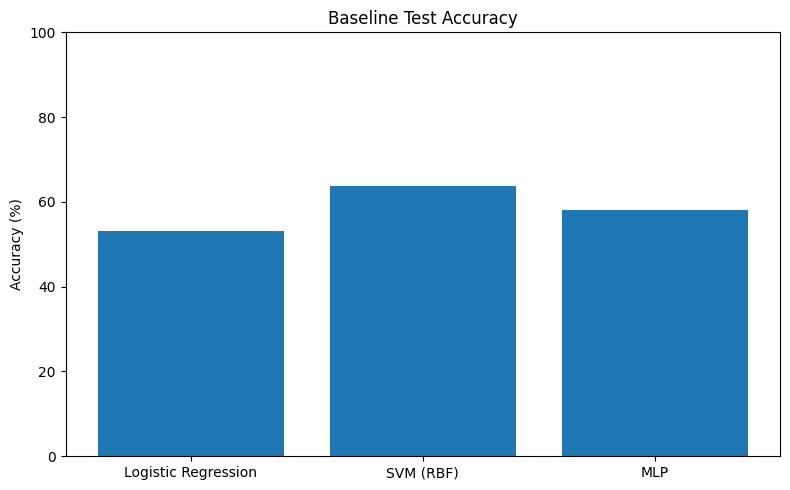

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_percent.index,
    comparison_percent["Accuracy"],
)

plt.title("Baseline Test Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

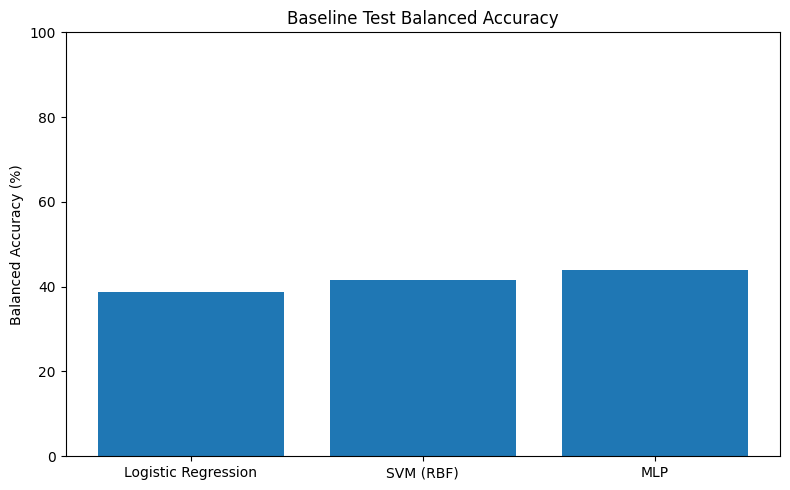

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_percent.index,
    comparison_percent["Balanced Accuracy"],
)

plt.title("Baseline Test Balanced Accuracy")
plt.ylabel("Balanced Accuracy (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

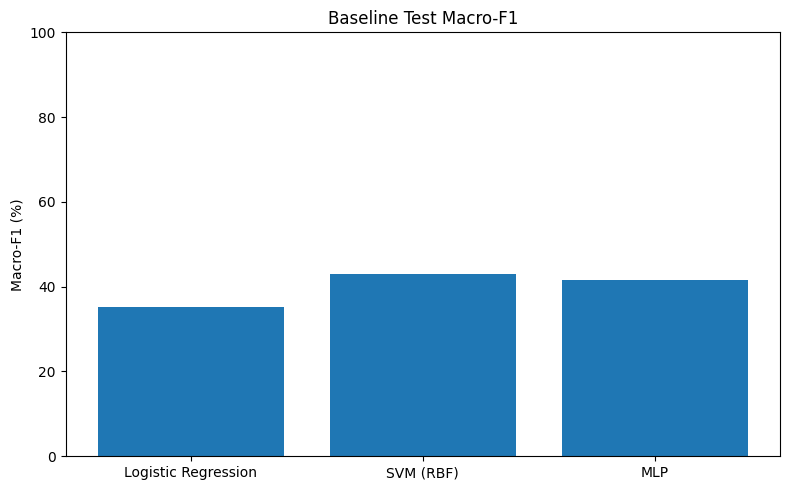

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_percent.index,
    comparison_percent["Macro-F1"],
)

plt.title("Baseline Test Macro-F1")
plt.ylabel("Macro-F1 (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

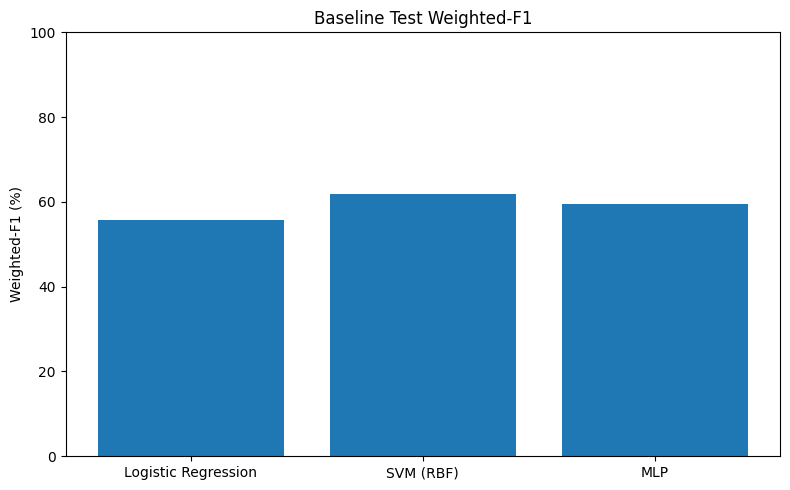

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_percent.index,
    comparison_percent["Weighted-F1"],
)

plt.title("Baseline Test Weighted-F1")
plt.ylabel("Weighted-F1 (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()